<a href="https://colab.research.google.com/github/manu93jadon/CI-CD-Project/blob/master/CO2_Emission_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries and Initial Setup

In [45]:
import requests

url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266"
filename = "CO2_Emissions.csv"

response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors

with open(filename, 'wb') as f:
    f.write(response.content)

print(f"Dataset downloaded successfully to {filename}")

Dataset downloaded successfully to CO2_Emissions.csv


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1 ) Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

In [47]:
emission_training_ds = pd.read_csv(filename)

In [48]:
emission_training_ds.info() #Check the info for nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

##Conclusion :


*   **No Nulls** are observed
*   **Multiple Fuel Consumption** metrics are provided, might be reduntant information for our model training


*   CO2 emission, the target variable is int64, we would require a **Regression Model**.
*   **Categorial Data** - 'Make', 'Model', 'Vehicle Class', 'Transmission', 'Fuel Type'



*   The components which we expect to have more telling impact on CO2 emissions are Engine Size and Type, Fuel Type and Vehicle Class
*   Tranmission Type might not really have very big impact on CO2 emission



#2)Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

### Data Quality Check

#### Check for unique values for every column

In [54]:
emission_training_ds.nunique()

,0
Make,42
Model,2053
Vehicle Class,16
Engine Size(L),51
Cylinders,8
Transmission,27
Fuel Type,5
Fuel Consumption City (L/100 km),211
Fuel Consumption Hwy (L/100 km),143
Fuel Consumption Comb (L/100 km),181


##### Observation - Very High Cardinality in training data, one hot encoding would create a very large dataset and might not be really useful in calculating CO2 emission, let us check if we can reduce number of model by only taking its company name

#### Check for Value Counts for every categorical column

In [53]:
categorical_cols = ['Make','Vehicle Class', 'Transmission', 'Fuel Type']
for i in categorical_cols:
    print(f"--- {i} ---")
    print(emission_training_ds[i].value_counts())



--- Make ---
Make
FORD             628
CHEVROLET        588
BMW              527
MERCEDES-BENZ    419
PORSCHE          376
TOYOTA           330
GMC              328
AUDI             286
NISSAN           259
JEEP             251
DODGE            246
KIA              231
HONDA            214
HYUNDAI          210
MINI             204
VOLKSWAGEN       197
MAZDA            180
LEXUS            178
JAGUAR           160
CADILLAC         158
SUBARU           140
VOLVO            124
INFINITI         108
BUICK            103
RAM               97
LINCOLN           96
MITSUBISHI        95
CHRYSLER          88
LAND ROVER        85
FIAT              73
ACURA             72
MASERATI          61
ROLLS-ROYCE       50
ASTON MARTIN      47
BENTLEY           46
LAMBORGHINI       41
ALFA ROMEO        30
GENESIS           25
SCION             22
SMART              7
BUGATTI            3
SRT                2
Name: count, dtype: int64
--- Vehicle Class ---
Vehicle Class
SUV - SMALL                 1217
MID-S

##### Observation - Fuel Type 'N' is just 1, can be dropped

#### Plot histplot and Boxplot to better understand our Data and Outliers

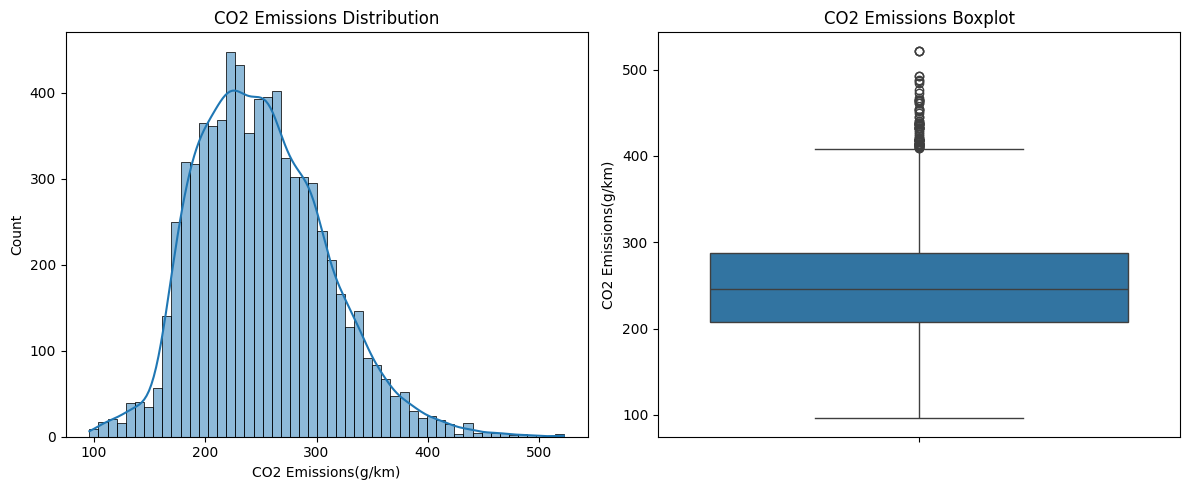

In [72]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(emission_training_ds["CO2 Emissions(g/km)"], kde=True)
plt.title("CO2 Emissions Distribution")

plt.subplot(1, 2, 2)
sns.boxplot(y=emission_training_ds["CO2 Emissions(g/km)"])
plt.title("CO2 Emissions Boxplot")

plt.tight_layout()
plt.show()

##### Observation -
Not Ideally Normal, bit more long tail on right side, 200 - 270 is where most vehicles lie. Right tail could be due to heavy vehicle or sports cars.
Boxplot shows high outliers for >400.

Linear Regression might fit our requirement here as normal distribution shape holds well. We will check for Assumptions of Normal Distribution

### Dataset Cleanup

In [74]:
#Dropping 'Model'
emission_training_ds_cleaned=emission_training_ds.drop('Model',axis=1)
#Dropping 'N' fuel type
emission_training_ds_cleaned = emission_training_ds_cleaned[emission_training_ds_cleaned['Fuel Type'] != 'N']


#3 ) Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

## Plotting for Correlation Matrix and Heatmap

Text(0.5, 1.0, 'Correlation Matrix')

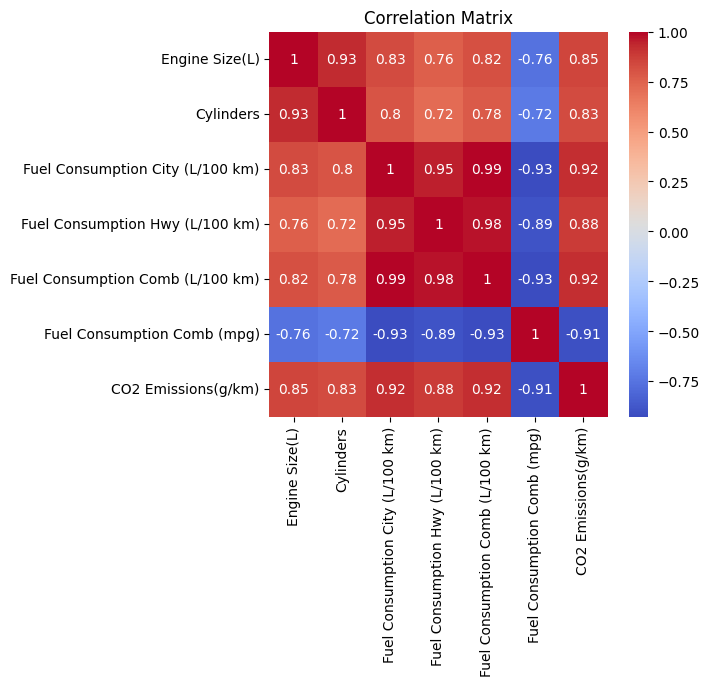

In [77]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(emission_training_ds_cleaned.corr(numeric_only=True),annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

##Observation -


1.   Very Evident that Multiple Fuel Consumption Parameters - Fuel Consumption City and Fuel Consumption Comb show very **high correlation** with each other
2.   Mathematical inverse - Fuel Consumption Comb(mpg) - Shows **inverse correlation** with rest of FC Metrices.
3. Engine Size, Fuel Consumption HWY and Fuel Consumption City/Comb have very big **influence on CO2 Emissions**





#4 ) Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

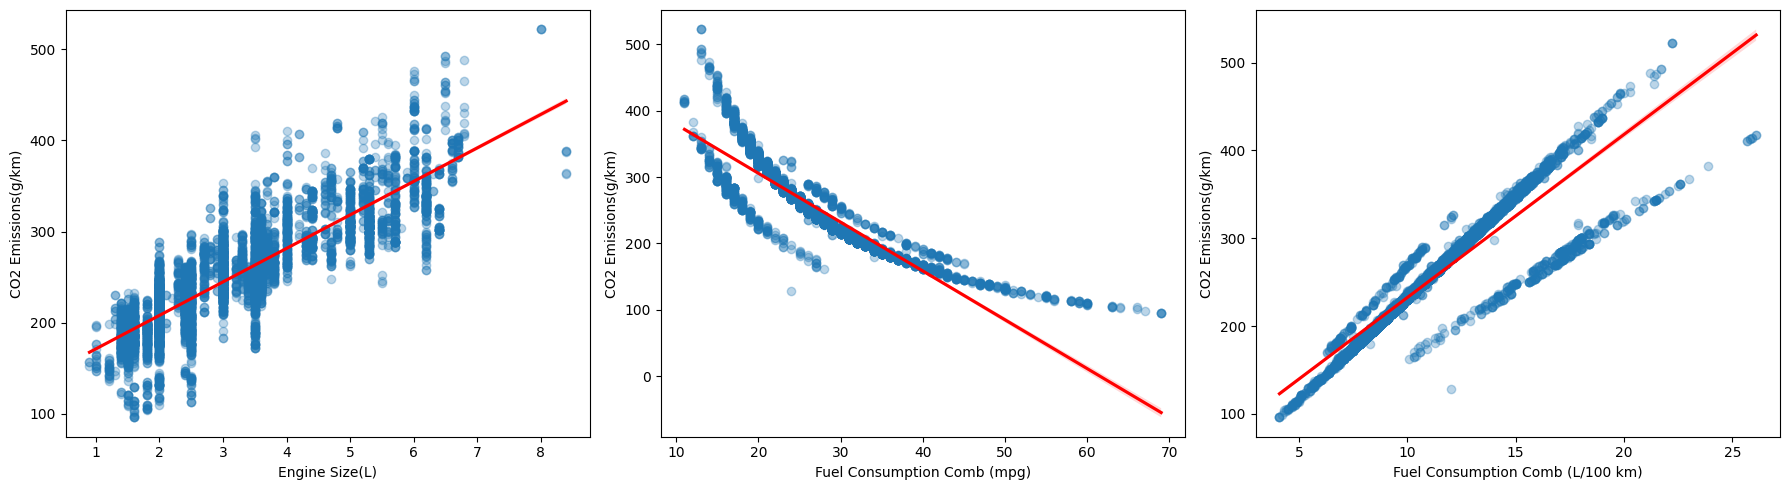

In [95]:
#We will use RegPlot to check Regression Trendline
plt.figure(figsize=(18, 5))
# Plot 1: Engine Size vs Emissions
plt.subplot(1, 3, 1)
sns.regplot(x='Engine Size(L)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.subplot(1, 3, 2)
# Plot 2: Fuel Consumption Comb(mpg) vs Emissions
sns.regplot(x='Fuel Consumption Comb (mpg)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.subplot(1, 3, 3)
# Plot 2: Fuel Consumption Comb (L/100 km) vs Emissions
sns.regplot(x='Fuel Consumption Comb (L/100 km)',y='CO2 Emissions(g/km)',data=emission_training_ds_cleaned,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.tight_layout()
plt.show()

### Observation:



*   Engine Size vs Emissions :
*   List item



